In [ ]:
#on your local terminal
wsl

In [ ]:
# ── 도킹 실습 전용 conda 환경 생성 ────────────────────────
# 이유: WSL2 base 환경의 conda solver가 도킹 패키지 설치 시
#       'Solving environment' 무한 대기 발생 → 전용 환경 분리

# 1. Python 3.10 기반 Miniconda 새로 설치
wget https://repo.anaconda.com/miniconda/Miniconda3-py310_23.11.0-2-Linux-x86_64.sh
bash Miniconda3-py310_23.11.0-2-Linux-x86_64.sh -b -p ~/miniconda310

# 2. 새 miniconda 활성화
source ~/miniconda310/etc/profile.d/conda.sh

# 3. conda 버전 확인
conda --version

# 4. docking 환경 생성 및 패키지 설치
conda create -n docking python=3.10 -y
conda activate docking
conda install -c conda-forge vina smina openbabel -y


AutoDockTools (Python 3 버전) 설치

In [ ]:
# 1. 소스 다운로드
cd ~
git clone https://github.com/Valdes-Tresanco-MS/AutoDockTools_py3.git
ls ~/AutoDockTools_py3/

In [ ]:
cd ~/AutoDockTools_py3
conda activate docking
python setup.py install

In [ ]:
pip install numpy
prepare_receptor4 --help
prepare_ligand4 --help

Quick Vina 2 설치

In [ ]:
cd ~
mkdir -p docking_tools
wget https://github.com/QVina/qvina/raw/master/bin/qvina02 -O ~/docking_tools/qvina02
chmod +x ~/docking_tools/qvina02
~/docking_tools/qvina02 --version

PBI Toolkit 설치

In [ ]:
cd ~
git clone https://github.com/gicsaw/PBI.git
cd PBI
python setup.py install

#if needed
## setup.py에서 fix_ligand.py 줄 제거
#sed -i '/fix_ligand.py/d' setup.py

## 재설치
#python setup.py install



---



# **실습** 1


## 리간드 전처리 워크플로우

### 각 Step 목적

| Step | 명령어 | 목적 |
|------|--------|------|
| 1 | `obabel ... -osmi` | PDB(3D) → SMILES(1D) 변환 |
| 2 | `obabel -p7.4` | 생리적 pH(7.4)에서 양성자화 상태 결정 |
| 3 | `obabel --gen3d` | SMILES → 3D conformer 생성 (MMFF94) |
| 4 | `gen3d.py` | 3D conformer 생성 + 원자 이름 고유 번호 부여 |
| 5 | `vimdiff` | 두 방법으로 생성된 파일 비교 |

## Step 1 — 리간드 SMILES 변환

목적: PDB 파일(3D 좌표 기반)을 SMILES(1D 문자열)로 변환. SMILES는 분자 구조를 텍스트로 표현하므로 이후 전처리 입력으로 사용.

In [ ]:
cd "/mnt/c/Users/PC/OneDrive - emocog/문서/Simoa_Jay/8)깃허브/LAIDD_drug_discovery/structure_based_drug_discovery/3_molecular_docking/3_1_docking_setup"

In [ ]:
~/miniconda310/envs/docking/bin/obabel TGFR1/pdb/3HMMA_855.pdb -osmi

In [ ]:
#Cc1cccc(n1)c1nc(c2ccccc2n1)Nc1ccncc1    TGFR1/pdb/3HMMA_855.pdb
#1 molecule converted

## Step 2 — pH 7.4 protonation state 계산

목적: 생리적 pH(7.4)에서 각 작용기의 양성자화 상태 결정. 예를 들어 아민(-NH₂)이 pH에 따라 양성(-NH₃⁺) 또는 중성으로 달라짐. 이 분자는 pH 7.4에서 변화 없음 → 중성 분자.

In [ ]:
#Cc1cccc(n1)c1nc(c2ccccc2n1)Nc1ccncc1
#1 molecule converted

## Step 3 — 3D conformer 생성 (obabel)

목적: SMILES(1D)에서 3D 좌표를 생성. 도킹은 3D 구조가 필요하므로 필수 단계. obabel은 MMFF94 force field로 에너지 최소화하여 3D 좌표 생성.

한계: 원자 이름이 C, N 등 원소 기호만으로 표기됨 → AutoDock 전처리에서 원자 구분 어려움.

In [ ]:
~/miniconda310/envs/docking/bin/obabel -:"Cc1cccc(n1)c1nc(c2ccccc2n1)Nc1ccncc1" --gen3d -O TGFR1/M855_0.pdb

## Step 4 — 3D conformer 생성 (gen3d.py, 원자 이름 변경 포함)

목적: obabel과 동일하게 3D 좌표를 생성하지만, 원자 이름을 C1, C2, N1 등으로 고유하게 번호 부여. AutoDock의 prepare_ligand4가 원자를 개별 식별하기 위해 고유 이름 필요.

In [ ]:
#cd ~/PBI
#~/miniconda310/envs/docking/bin/python setup.py install

#~/miniconda310/envs/docking/bin/pip install rdkit

#~/miniconda310/envs/docking/bin/pip install openmm

#~/miniconda310/envs/docking/bin/pip install pdbfixer

In [ ]:
~/miniconda310/envs/docking/bin/gen3d.py -i "Cc1cccc(n1)c1nc(c2ccccc2n1)Nc1ccncc1" -o TGFR1/M855.pdb

## Step 5 — 두 파일 비교

In [ ]:
vimdiff TGFR1/M855.pdb TGFR1/M855_0.pdb

In [ ]:
#vimdiff 종료: Esc → :qa! → Enter

### obabel vs gen3d.py 비교


| 항목 | M855_0.pdb (obabel) | M855.pdb (gen3d.py) |
|------|---------------------|---------------------|
| 원자 이름 | `C`, `N` (중복) | `C1`, `C2`, `N1` (고유) |
| 최적화 방법 | MMFF94 force field | RDKit 기반 |
| 용도 | 참고용 | 도킹 전처리 입력용  |

> **gen3d.py를 사용하는 이유:** AutoDock의 `prepare_ligand4`가 원자를 개별 식별하기 위해 고유한 원자 이름 필요.




---



# **실습** 2


## Chimera GUI를 활용한 AutoDock Vina 도킹

In [ ]:
#download UCSF Chimera
	https://www.cgl.ucsf.edu/chimera/download.html

In [ ]:
#download AutoDock Vina 1.2.3 (Windows)
https://github.com/ccsb-scripps/AutoDock-Vina/releases/tag/v1.2.3

## Step 1 — 파일 열기

File → Open → receptor 파일 선택 → Open

File → Open → ligand 파일 선택 → Open

Receptor: 3HMMA_receptor_HOH.pdb

Ligand: 3HMMA_855.pdb

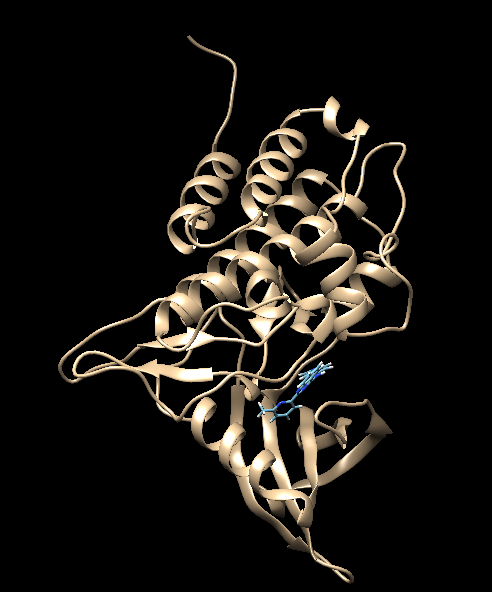

## Step 2 — AutoDock Vina 플러그인 실행

Tools → Surface/Binding Analysis → AutoDock Vina

## Step 3 — 도킹 파라미터 설정

## Chimera AutoDock Vina 파라미터 설정

| 항목 | 값 |
|------|-----|
| Output file | `C:/Users/PC/docking_GUI/out.pdbqt` (한글 없는 경로) |
| Receptor | `3HMMA_receptor_HOH.pdb` |
| Ligand | `3HMMA_855.pdb` |
| Center X | 17.994 |
| Center Y | 68.852 |
| Center Z | 7.446 |
| Size X | 26.718 |
| Size Y | 19.984 |
| Size Z | 22.033 |
| Vina 실행파일 | `vina_1.2.3_windows_x86_64.exe` 전체 경로 지정 |

> ⚠️ **주의:** Output file 및 Vina 실행파일 경로에 **한글 포함 금지**

## Step 4 — 도킹 실행

OK 버튼 클릭

## Step 5 — 결과 확인

Chimera 뷰어: 결합 자세 시각화

ViewDock: Score / RMSD 테이블 확인

---
### Chimera 마우스 조작법

| 동작 | 마우스 |
|------|--------|
| 회전 | 좌클릭 드래그 |
| 줌인/아웃 | 우클릭 드래그 |
| 수평 이동 | 휠 클릭 드래그 |

### Chimera 도킹 결과 파일 구조

| 파일 | 내용 |
|------|------|
| `out.conf` | Vina 파라미터 설정 파일 |
| `out.receptor.pdb` | 도킹용 수용체 원본 |
| `out.receptor.pdbqt` | 도킹용 수용체 (PDBQT 형식) |
| `out.ligand.pdb` | 도킹용 리간드 초기 구조 |
| `out.ligand.pdbqt` | 도킹용 리간드 초기 구조 (PDBQT 형식) |
| `out.pdbqt` | **도킹 결과** — 모든 결합 자세 + 스코어 |

> **PDBQT:** AutoDock 계열 전용 파일 형식.  
> PDB에 **원자 타입(q)** 과 **부분 전하(t)** 정보가 추가된 형식.

---

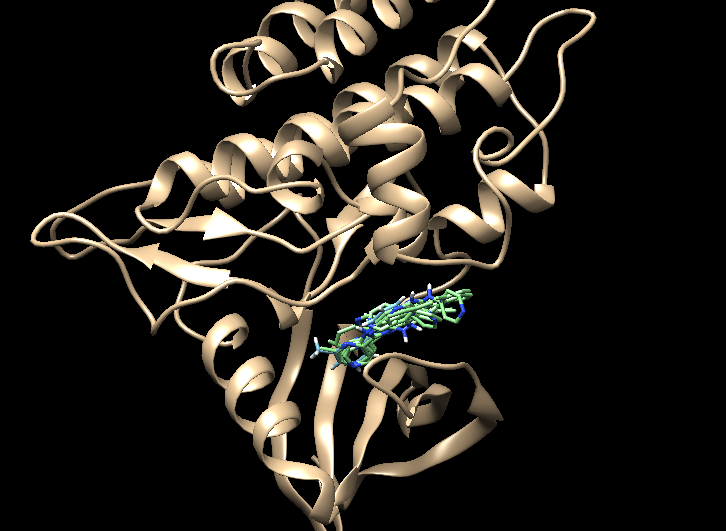

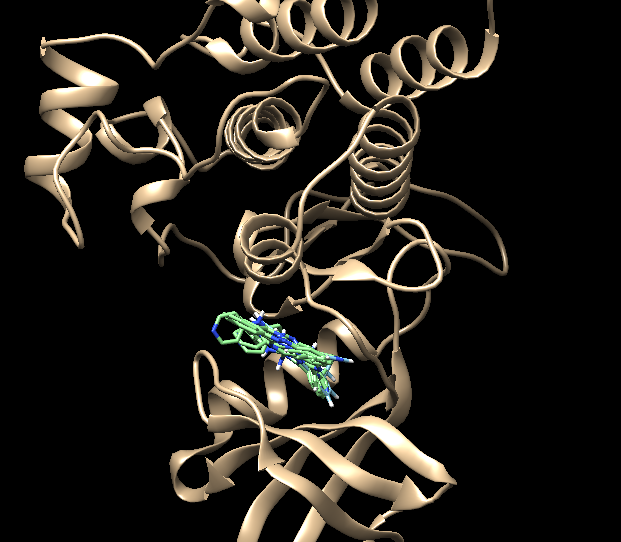

### Chimera GUI 도킹 결과 (3HMM — 리간드 855); check ViewDock

| Rank | Score (kcal/mol) | RMSD lb (Å) | RMSD ub (Å) | 해석 |
|------|-----------------|-------------|-------------|------|
| 1 | **-10.588** | 0.000 | 0.000 | 최적 결합 자세 (reference) ✅ |
| 2 | -9.668 | 1.185 | 5.917 | 유사 자세 |
| 3 | -9.030 | 1.727 | 6.757 | 유사 자세 |
| 4 | -9.027 | 1.715 | 5.207 | 유사 자세 |
| 5 | -8.971 | 1.765 | 6.945 | 다른 자세 |

#### 평가

- **Score -10.588 kcal/mol** → 강한 결합 친화도 (통상 -8 kcal/mol 이하면 강한 결합으로 간주)
- **Rank 1 RMSD = 0.000 Å** → 결정 구조(3HMM) 실제 리간드 자세와 동일하게 재현 성공 ✅
- **Rank 2-4 RMSD lb < 2 Å** → 결정 구조와 매우 유사한 자세들
- **RMSD ub > 5 Å** → 전체 구조 편차는 존재하나, 결합 포켓 내 핵심 상호작용은 유사

> **Score:** 낮을수록(음수가 클수록) 결합 친화도 높음  
> **RMSD lb:** 가장 유사한 상위 자세 대비 편차 <br>
> **RMSD ub:** 최적 자세(Rank 1) 대비 편차 <br>
> Rank 1의 RMSD = 0.000 → 결정 구조와 동일한 결합 자세 재현 성공

---
### Rank 1 상세 에너지 분석

#### 에너지 분해 (Energy Decomposition)

| 항목 | 값 (kcal/mol) | 설명 |
|------|--------------|------|
| **VINA RESULT** | **-10.588** | 최종 결합 친화도 (binding affinity) |
| INTER + INTRA | -13.247 | 단백질-리간드 상호작용 + 리간드 내부 에너지 합 |
| INTER | -12.973 | 단백질-리간드 간 상호작용 에너지 |
| INTRA | -0.273 | 리간드 내부 에너지 |
| UNBOUND | -0.802 | 결합 전 리간드 자유 에너지 |

> **계산식:** VINA RESULT = INTER + INTRA − UNBOUND  
> = -13.247 − (-0.802) = **-12.445** (근사)



*   INTER (-12.973 kcal/mol): 단백질(Receptor)과 약물(Ligand) 사이의 순수한 끌어당김(수소결합, 소수성 상호작용 등)입니다. 이 값이 매우 큰 마이너스라는 것은 약물이 단백질 포켓에 아주 찰떡같이 잘 들어맞았음을 뜻합니다.
*  INTRA (-0.273 kcal/mol): 약물 분자 '내부' 원자들끼리의 부딪힘이나 꺾임에서 오는 에너지입니다. 0에 가까운 작은 마이너스 값이라는 것은, 약물이 단백질에 결합하기 위해 스스로를 억지로 비틀거나 찌그러뜨리지 않고 매우 편안하고 안정적인 자세(Conformation)를 유지하고 있음을 의미합니다.
*   핵심 포인트 (엔트로피 페널티의 증명):계산식에서 순수 에너지의 합은 -12.445 kcal/mol이 나왔습니다. 하지만 최종 결과인 VINA RESULT는 -10.588 kcal/mol입니다. 점수가 약 1.85점 정도 깎였습니다.이 깎여나간 점수가 바로 앞서 설명해 드렸던 회전 가능한 결합($N_{rot}$) 때문에 발생하는 '형태적 엔트로피 페널티'입니다. 단백질과 잘 결합하긴 했지만, 분자의 유연성을 희생한 대가로 열역학적 점수를 삭감당한 구조를 정확히 보여줍니다.

---

#### 활성 비틀림 (Active Torsions)

| # | 상태 | 결합 원자 쌍 | 의미 |
|---|------|-------------|------|
| 1 | A (Active) | C6 — C8 | 회전 가능한 단일 결합 |
| 2 | A (Active) | C10 — N5 | 회전 가능한 단일 결합 |
| 3 | A (Active) | C12 — N5 | 회전 가능한 단일 결합 |

> **Active torsion 3개** → 도킹 탐색 자유도 3개  
> 비틀림 수가 많을수록 탐색 공간이 넓어져 계산 시간 증가  
> Amide 및 guanidinium 결합은 기본적으로 비활성(Inactive) 처리

이 섹션은 약물이 도킹 과정에서 얼마나 춤을 추듯 유연하게 움직였는지를 나타냅니다.
*   탐색 자유도 3개 ($N_{rot} = 3$): 이 리간드는 C6-C8, C10-N5, C12-N5라는 3개의 단일 결합 축을 중심으로 팽이처럼 빙글빙글 돌며 최적의 결합 위치를 탐색했습니다. 3개면 상당히 뻣뻣하고 안정적인(Rigid) 분자에 속하며, 앞서 본 엔트로피 페널티를 상대적으로 적게 받아 높은 최종 점수(-10.588)를 유지할 수 있었던 비결이기도 합니다. (신약 후보 물질로서 아주 좋은 지표입니다.)
*  Amide 등은 비활성(Inactive) 처리: 표 하단의 설명에 아미드(Amide) 결합은 회전시키지 않았다는 문구가 있습니다. 이는 방금 전 우리가 텍스트로 보았던 "펩타이드 결합(Amide bond)은 부분적 이중 결합 성질을 띠어 평면을 유지한다"는 화학적 지식을 Vina 프로그램이 스스로 인지하고, 구조 탐색 시 해당 결합은 강체(Rigid)처럼 뻣뻣하게 고정해 두었다는 뜻입니다.



---



# **실습** 3


## 리눅스 터미널 환경에서 AutoDock Vina 도킹

In [ ]:
conda activate docking

In [ ]:
# Step 1 — receptor PDBQT 변환
prepare_receptor4 -U nphs_lps -r 3HMMA_receptor_HOH.pdb -o 3HMMA_receptor_HOH.pdbqt

In [ ]:
ls *.pdbqt

In [ ]:
# Step 2 — ligand PDBQT 변환
prepare_ligand4 -U nphs_lps -l 3HMMA_855.pdb -o 3HMMA_855.pdbqt

In [ ]:
# Step 3 - config.text
# config.txt 생성
cat > config.txt << 'EOF'
receptor=3HMMA_receptor_HOH.pdbqt
center_x=17.994
center_y=68.852
center_z=7.446
size_x=26.718
size_y=19.984
size_z=22.033
cpu=10
num_modes=10
exhaustiveness=10
EOF

In [ ]:
# 확인
cat config.txt

In [ ]:
# Step 4 - 도킹 실행
~/docking_tools/qvina02 --config config.txt --ligand 3HMMA_855.pdbqt --out dock_3HMMA_855.pdbqt

## Quick Vina 2 도킹 결과 (3HMM — 리간드 855)

| Mode | Score (kcal/mol) | RMSD lb (Å) | RMSD ub (Å) |
|------|-----------------|-------------|-------------|
| **1** | **-11.4** | 0.000 | 0.000 |
| 2 | -10.3 | 1.089 | 5.849 |
| 3 | -10.2 | 1.695 | 2.119 |
| 4 | -9.5 | 1.795 | 6.835 |
| 5 | -9.3 | 1.779 | 6.877 |
| 6~10 | -9.1 ~ -8.8 | 2.3 ~ 3.2 | 6.3 ~ 8.0 |

### 평가

- **Score -11.4 kcal/mol** → Chimera GUI 결과(-10.588)보다 더 강한 결합 친화도 예측
- **계산 시간 1.955초** → 매우 빠른 탐색 (Quick Vina 2의 장점)
- **Mode 1 RMSD = 0.000 Å** → 기준 자세 (reference)
- **Mode 2-3 RMSD lb < 2 Å** → 결정 구조와 매우 유사한 자세

---

## Chimera GUI vs Quick Vina 2 비교

| 항목 | Chimera GUI (Vina 1.2.3) | Quick Vina 2 |
|------|--------------------------|--------------|
| Rank 1 Score | -10.588 kcal/mol | **-11.4 kcal/mol** |
| 계산 속도 | 상대적으로 느림 | **1.955초** |
| 사용 편의성 | GUI (직관적) | CLI (자동화 가능) |
| 적합한 용도 | 단일 구조 확인 | 대규모 가상 탐색 |

In [ ]:
# Step 5 - 결과 구조 시각화

## 심볼릭 링크로 /usr/local/bin에 등록
#sudo ln -sf ~/miniconda310/envs/docking/bin/obabel /usr/local/bin/obabel
## 확인
#which obabel

~/miniconda310/envs/docking/bin/pdbqt2pdb_ref.py -i dock_3HMMA_855.pdbqt -o dock_3HMMA_855.pdb -r 3HMMA_855.pdb

In [ ]:
# 결과 파일 확인
ls dock_3HMMA_855.pdb
head -5 dock_3HMMA_855.pdb

In [ ]:
# PyMOL 콘솔에서 시각화
cd C:/Users/PC/OneDrive - emocog/문서/Simoa_Jay/8)깃허브/LAIDD_drug_discovery/structure_based_drug_discovery/3_molecular_docking/3_1_docking_setup
load 3HMMA_receptor_HOH.pdb
load 3HMMA_855.pdb
load dock_3HMMA_855.pdb

# 단백질 cartoon, 리간드 stick으로 표시
hide everything
show cartoon, 3HMMA_receptor_HOH
show sticks, 3HMMA_855
show sticks, dock_3HMMA_855

# 색상 구분
color cyan, 3HMMA_receptor_HOH
color yellow, 3HMMA_855
color magenta, dock_3HMMA_855

# 화면 맞추기
zoom

# 단백질 기준으로 전체 정렬
align dock_3HMMA_855, 3HMMA_855

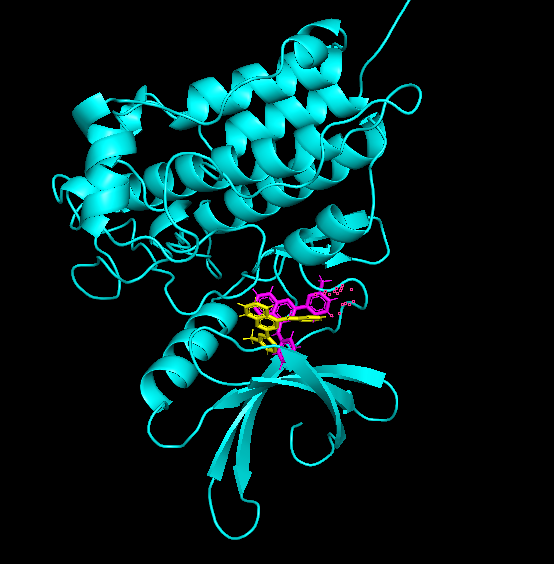